# Topic Modeling of U.S. Earnings Call Transcripts (2025–2026)
#
# This notebook performs LDA topic modeling on a corpus of ~2,900 earnings call
# transcripts scraped from investing.com. For full context — research motivation,
# project goals, and the link to the underlying Master Thesis — see README.md.
#
# Pipeline: R (00_prepare_corpus.R) → Python/gensim (this notebook) → R/ggplot2 (02_visualize_topics.R)
# Outputs:  data/doc_topic_distributions.csv, data/topic_terms.csv, data/role_topic_comparison.csv

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re
import os
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Topic modeling
from gensim import corpora, models
from gensim.models import CoherenceModel

# Download required NLTK data (only runs if not yet downloaded)
for resource in ['punkt', 'stopwords', 'wordnet', 'averaged_perceptron_tagger', 'punkt_tab']:
    try:
        nltk.data.find(f'tokenizers/{resource}' if 'punkt' in resource else f'corpora/{resource}')
    except LookupError:
        nltk.download(resource, quiet=True)

print(f"pandas {pd.__version__}, numpy {np.__version__}")
print("Setup complete.")

pandas 2.3.3, numpy 1.26.4
Setup complete.


[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:997)>
[nltk_data] Error loading averaged_perceptron_tagger: <urlopen error
[nltk_data]     [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify
[nltk_data]     failed: unable to get local issuer certificate
[nltk_data]     (_ssl.c:997)>


## 1. Loading and Describing the Corpus

The corpus was assembled from ~2,969 individual transcript RDS files using `00_prepare_corpus.R`. Each row in the CSV corresponds to one earnings call transcript, with the full text of all speakers (excluding the call operator) concatenated into a single document.

In [2]:
# Load the document-level corpus prepared by 00_prepare_corpus.R
docs = pd.read_csv('data/corpus_documents.csv', parse_dates=['call_date', 'call_month'])

print(f"Corpus size: {len(docs):,} transcripts")
print(f"Date range:  {docs['call_date'].min().date()} → {docs['call_date'].max().date()}")
print(f"Companies:   {docs['company_name'].nunique():,} unique")
print(f"\nWord count distribution:")
print(docs['n_words'].describe().round(0).astype(int))

Corpus size: 2,907 transcripts
Date range:  2001-01-01 → 2026-03-02
Companies:   2,629 unique

Word count distribution:
count    2907
mean     2979
std      1470
min       101
25%      1988
50%      2989
75%      3942
max      9386
Name: n_words, dtype: int64


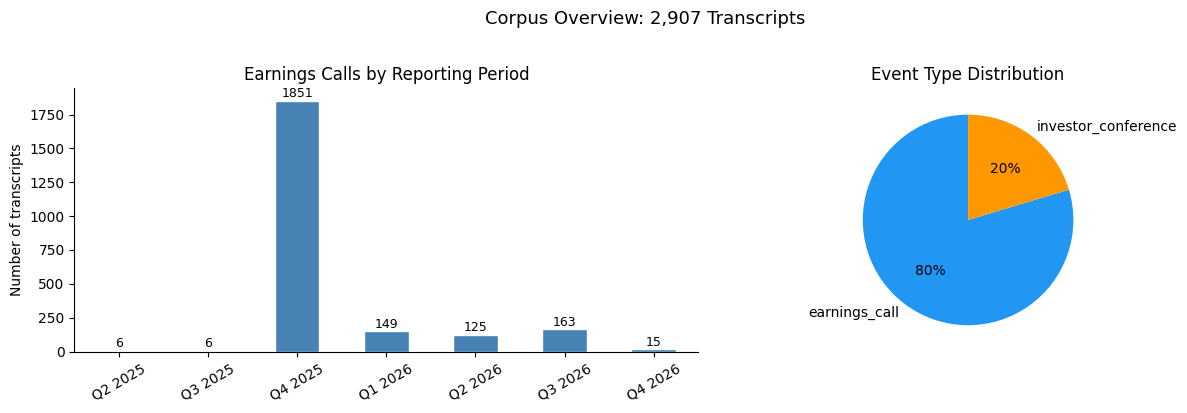

Q4 2025 dominates because the scraper ran during the Feb 2026 earnings season.
Non-calendar-FY companies appear as Q1/Q2/Q3 2026.


In [3]:
# --- Corpus composition by reporting period and event type ---
# The primary temporal dimension is the *reporting period* (fiscal quarter reported),
# not the publication month. Most transcripts report Q4 2025 results, but the corpus
# also includes Q1–Q3 2026 calls for companies with non-calendar fiscal years,
# plus ~590 investor conference presentations (no assigned quarter).

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left panel: earnings calls by reporting period
period_order = ['Q2 2025', 'Q3 2025', 'Q4 2025', 'Q1 2026', 'Q2 2026', 'Q3 2026', 'Q4 2026']
period_counts = (docs[docs['reporting_period'].notna()]
                 .groupby('reporting_period').size().reindex(period_order).dropna())
period_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Earnings Calls by Reporting Period', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of transcripts')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(period_counts):
    axes[0].text(i, v + 5, str(int(v)), ha='center', va='bottom', fontsize=9)
axes[0].spines[['top', 'right']].set_visible(False)

# Right panel: event type breakdown
event_counts = docs['event_type'].fillna('unknown').value_counts()
axes[1].pie(event_counts, labels=event_counts.index, autopct='%1.0f%%',
            colors=['#2196F3', '#FF9800'], startangle=90)
axes[1].set_title('Event Type Distribution', fontsize=12)

fig.suptitle(f'Corpus Overview: {len(docs):,} Transcripts', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('figures/00_corpus_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Q4 2025 dominates because the scraper ran during the Feb 2026 earnings season.")
print("Non-calendar-FY companies appear as Q1/Q2/Q3 2026.")

In [4]:
# --- Quarter distribution ---
# Most transcripts are Q4 2025 earnings, with some Q3 2025 and a few Q1/Q2

quarter_counts = docs.groupby(['call_year', 'quarter']).size().reset_index(name='n')
print("Documents by year and quarter:")
print(quarter_counts.to_string(index=False))

Documents by year and quarter:
 call_year quarter    n
    2025.0      Q2    6
    2025.0      Q3    6
    2025.0      Q4 1851
    2026.0      Q1  149
    2026.0      Q2  125
    2026.0      Q3  163
    2026.0      Q4   15


## 2. Text Preprocessing

LDA operates on a **bag-of-words** representation — word order is discarded, and each document becomes a frequency vector over a shared vocabulary. Good preprocessing is therefore critical to topic quality.

We apply the following pipeline:
1. **Lowercase** and remove punctuation/numbers
2. **Tokenize** (split into words)
3. **Remove stopwords** — standard English + a custom earnings-call stoplist capturing boilerplate phrases (*thank you for joining, forward-looking statements*, etc.)
4. **Lemmatize** — reduce inflected forms to their base form (*growing → grow*, *revenues → revenue*)
5. **Filter by length** — keep tokens of 3+ characters
6. **Remove rare and very common tokens** — tokens appearing in fewer than 5 documents or more than 80% of documents add noise

In [5]:
# --- Custom stopwords for earnings call boilerplate ---
# Two categories:
#   (1) Standard filler/function words not caught by NLTK's English stoplist
#   (2) Domain-specific boilerplate that appears in nearly every earnings call
#       but carries no discriminative topical information.
# Words are removed iteratively by inspecting the top-frequency terms after
# each pass (see figures/01_top_terms_corpus.png).

EARNINGS_STOPWORDS = {
    # --- Spoken-language fillers and hedges ---
    'like', 'would', 'could', 'also', 'see', 'get', 'got', 'say', 'said',
    'maybe', 'yes', 'yeah', 'okay', 'right', 'sure', 'well', 'actually',
    'really', 'think', 'know', 'going', 'lot', 'kind', 'thing', 'things',
    'good', 'great', 'much', 'bit', 'little', 'sort', 'mean', 'means',
    'way', 'back', 'come', 'came', 'comes', 'coming', 'look', 'looking',
    'take', 'taking', 'took',
    'want', 'need', 'make', 'made', 'let', 'still', 'already', 'quite',
    'obviously', 'guess', 'hmm', 'gon', 'guy', 'guys', 'hey', 'sir',
    'across', 'around', 'ahead', 'today', 'morning', 'afternoon', 'please',
    'ask', 'asked', 'talk', 'talked', 'work', 'worked', 'working',
    'new', 'high', 'higher', 'low', 'lower', 'long', 'short',
    'half', 'part', 'level', 'side', 'course', 'slide',
    'better', 'pretty', 'couple', 'seen', 'able', 'big', 'different',
    'appreciate', 'follow', 'mix', 'give', 'given', 'mentioned',
    'something', 'done', 'feel', 'every', 'probably', 'certainly',
    'clear', 'positive', 'based', 'every', 'versus',
    # Modal/auxiliary verbs the lemmatizer leaves unfiltered
    'may', 'might', 'shall',

    # --- Generic temporal markers ---
    'time', 'term', 'end', 'ago',

    # --- Generic financial/corporate boilerplate ---
    'quarter', 'year', 'fiscal', 'full', 'first', 'second', 'third', 'fourth',
    'q1', 'q2', 'q3', 'q4', 'fy', 'fy25', 'fy26',
    'company', 'business', 'team', 'call', 'conference', 'joining',
    'result', 'results', 'report', 'reported', 'period',
    'basis', 'point', 'per', 'share', 'million', 'billion',
    'next', 'last', 'prior', 'current', 'previous',
    'one', 'two', 'three', 'four', 'five', 'number',
    'performance', 'earnings', 'net', 'sale', 'adjusted',

    # --- Call protocol boilerplate ---
    'forward', 'looking', 'statement', 'statements', 'sec', 'filing',
    'caution', 'risk', 'risks', 'actual', 'differ', 'materially',
    'operator', 'line', 'open', 'proceed', 'queue',
    'remark', 'press', 'star', 'turn', 'welcome',
    'thank', 'thanks', 'question', 'answer',
    'begin', 'session', 'telephone', 'release', 'future', 'afternoon',
    'presentation', 'investor', 'officer', 'chief',

    # --- Generic cross-topic words that add noise ---
    'people', 'center', 'power', 'seeing', 'demand', 'supply', 'order',
    'data', 'service', 'program', 'plan', 'use', 'used', 'using',
    'increase', 'decrease', 'grow', 'expect', 'expected',
    'include', 'continue', 'drive', 'driven', 'impact',
    'important', 'able',
}

# Combine with standard English stopwords
STOP_WORDS = set(stopwords.words('english')) | EARNINGS_STOPWORDS

lemmatizer = WordNetLemmatizer()

def preprocess(text):
    """Clean and tokenize a single document."""
    if not isinstance(text, str) or len(text) < 50:
        return []
    # Lowercase and remove non-alphabetic characters
    text = re.sub(r'[^a-z\s]', ' ', text.lower())
    # Tokenize
    tokens = word_tokenize(text)
    # Filter: length >= 3, not a stopword, lemmatize
    tokens = [
        lemmatizer.lemmatize(t)
        for t in tokens
        if len(t) >= 3 and t not in STOP_WORDS and t.isalpha()
    ]
    return tokens

# Run preprocessing (~1-2 minutes on 2,900 documents)
print("Preprocessing documents...")
tokenized = [preprocess(text) for text in docs['full_text']]

# Show a preprocessing example
idx = 10
print(f"\nExample — {docs.iloc[idx]['company_name']}")
print(f"  Raw (first 200 chars): {docs.iloc[idx]['full_text'][:200]}")
print(f"  Tokens (first 20):     {tokenized[idx][:20]}")
print(f"\nToken count stats after preprocessing:")
token_lengths = [len(t) for t in tokenized]
print(f"  Mean tokens/doc:   {np.mean(token_lengths):.0f}")
print(f"  Median tokens/doc: {np.median(token_lengths):.0f}")
print(f"  Docs with < 50 tokens: {sum(l < 50 for l in token_lengths)}")

Preprocessing documents...



Example — Emerging Growth Virtual Conference
  Raw (first 200 chars): I’d like to welcome back James B. Frakes, CEO and CFO, and Steven LaRosa, Chief Medical Officer of Aethlon Medical. Aethlon is a medical therapeutic company focused on developing products to treat can
  Tokens (first 20):     ['james', 'frakes', 'ceo', 'cfo', 'steven', 'larosa', 'medical', 'aethlon', 'medical', 'aethlon', 'medical', 'therapeutic', 'focused', 'developing', 'product', 'treat', 'cancer', 'life', 'threatening', 'infectious']

Token count stats after preprocessing:
  Mean tokens/doc:   856
  Median tokens/doc: 862
  Docs with < 50 tokens: 25


In [6]:
# --- Build the gensim dictionary and bag-of-words corpus ---

# Filter out documents that are too short after preprocessing
MIN_TOKENS = 50
valid_idx = [i for i, t in enumerate(tokenized) if len(t) >= MIN_TOKENS]
tokenized_clean = [tokenized[i] for i in valid_idx]
docs_clean = docs.iloc[valid_idx].reset_index(drop=True)

print(f"Documents retained (≥{MIN_TOKENS} tokens): {len(docs_clean):,}")

# Build dictionary: maps each unique token to an integer ID
dictionary = corpora.Dictionary(tokenized_clean)
print(f"Vocabulary before filtering: {len(dictionary):,} tokens")

# Filter extremes: remove tokens in fewer than 5 docs or more than 80% of docs
dictionary.filter_extremes(no_below=5, no_above=0.80)
print(f"Vocabulary after filtering:  {len(dictionary):,} tokens")

# Convert to bag-of-words representation
bow_corpus = [dictionary.doc2bow(doc) for doc in tokenized_clean]
print(f"Corpus ready: {len(bow_corpus):,} documents")

Documents retained (≥50 tokens): 2,882


Vocabulary before filtering: 52,065 tokens
Vocabulary after filtering:  13,154 tokens


Corpus ready: 2,882 documents


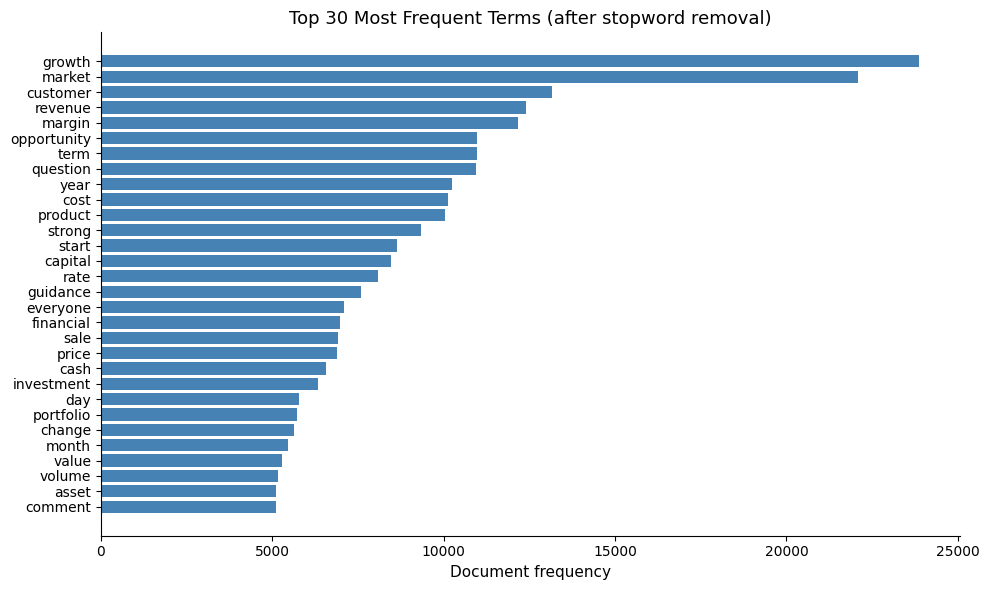

In [7]:
# --- Most frequent terms in the full corpus (word frequency profile) ---
# This gives a first intuition about the vocabulary before topic modeling.

from collections import Counter

all_tokens = [tok for doc in tokenized_clean for tok in doc]
top_terms = Counter(all_tokens).most_common(30)

terms_df = pd.DataFrame(top_terms, columns=['term', 'count'])

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(terms_df['term'][::-1], terms_df['count'][::-1], color='steelblue')
ax.set_title('Top 30 Most Frequent Terms (after stopword removal)', fontsize=13)
ax.set_xlabel('Document frequency', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('figures/01_top_terms_corpus.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. LDA Topic Modeling

### 3a. Selecting the Number of Topics (K)

LDA requires specifying K (number of topics) in advance. We use **topic coherence** (c_v metric) to guide this choice: coherence measures how semantically similar the top words of a topic are, using pointwise mutual information over a reference corpus. Higher coherence = more interpretable topics.

We evaluate K ∈ {5, 8, 10, 12, 15, 18, 20} on a stratified sample of the corpus.

In [8]:
# --- Coherence scoring over a range of K values ---
# We use a sample for speed; the full corpus is used for the final model.

# Use up to 1500 docs for K selection
np.random.seed(42)
sample_size = min(1500, len(bow_corpus))
sample_idx = np.random.choice(len(bow_corpus), sample_size, replace=False)
sample_bow  = [bow_corpus[i] for i in sample_idx]
sample_tok  = [tokenized_clean[i] for i in sample_idx]

K_values = [5, 8, 10, 12, 15, 18, 20]
coherence_scores = []

print("Computing coherence for K =", K_values)
for k in K_values:
    lda_tmp = models.LdaModel(
        corpus=sample_bow,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=5,
        alpha='auto'
    )
    cm = CoherenceModel(model=lda_tmp, texts=sample_tok,
                        dictionary=dictionary, coherence='c_v')
    score = cm.get_coherence()
    coherence_scores.append(score)
    print(f"  K={k:2d}  coherence={score:.4f}")

Computing coherence for K = [5, 8, 10, 12, 15, 18, 20]


  K= 5  coherence=0.2573


  K= 8  coherence=0.2737


  K=10  coherence=0.2731


  K=12  coherence=0.2872


  K=15  coherence=0.2949


  K=18  coherence=0.3072


  K=20  coherence=0.3107


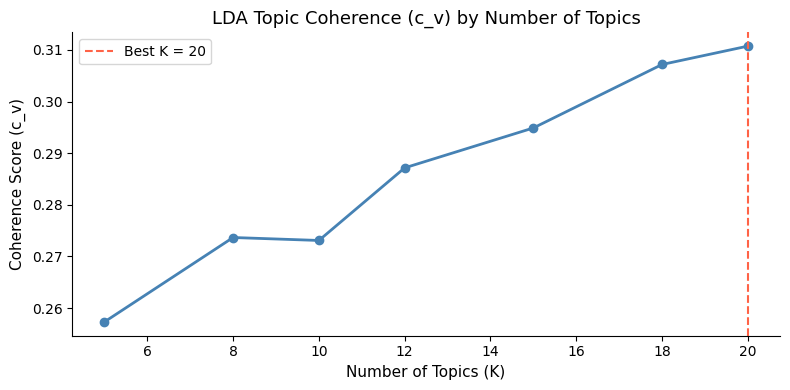

Selected K = 20 based on peak coherence


In [9]:
# --- Plot coherence curve ---

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_values, coherence_scores, marker='o', linewidth=2, color='steelblue')
best_k = K_values[np.argmax(coherence_scores)]
ax.axvline(best_k, linestyle='--', color='tomato', label=f'Best K = {best_k}')
ax.set_title('LDA Topic Coherence (c_v) by Number of Topics', fontsize=13)
ax.set_xlabel('Number of Topics (K)', fontsize=11)
ax.set_ylabel('Coherence Score (c_v)', fontsize=11)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('figures/02_coherence_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Selected K = {best_k} based on peak coherence")

### 3b. Fitting the Final LDA Model

We fit the final model on the full corpus using the K that maximized coherence. We use `alpha='auto'` to let the model learn asymmetric topic priors from the data (some topics may be more prevalent than others).

In [10]:
# --- Fit final LDA model on full corpus ---

# Allow manual override: if the coherence peak seems noisy,
# you can set K manually here.
K_FINAL = best_k  # or set manually, e.g. K_FINAL = 15

print(f"Fitting LDA with K={K_FINAL} on {len(bow_corpus):,} documents...")

lda_model = models.LdaModel(
    corpus=bow_corpus,
    id2word=dictionary,
    num_topics=K_FINAL,
    random_state=42,
    passes=15,          # more passes = better convergence
    alpha='auto',       # learn asymmetric topic prior
    eta='auto',         # learn asymmetric word prior
    minimum_probability=0.0  # keep all topics in output
)

# Final coherence on full corpus
cm_final = CoherenceModel(model=lda_model, texts=tokenized_clean,
                           dictionary=dictionary, coherence='c_v')
print(f"Final model coherence (c_v): {cm_final.get_coherence():.4f}")

Fitting LDA with K=20 on 2,882 documents...


Final model coherence (c_v): 0.4074


## 4. Topic Exploration

Each topic is a probability distribution over the vocabulary. We examine the top terms per topic and manually assign interpretive labels — this labeling step requires human judgment and domain knowledge.

In [11]:
# --- Print top 15 terms per topic ---

N_TOP_WORDS = 15

print(f"Top {N_TOP_WORDS} terms per topic:\n")
for i in range(K_FINAL):
    terms = lda_model.show_topic(i, topn=N_TOP_WORDS)
    term_str = ', '.join([f"{w}({p:.3f})" for w, p in terms])
    print(f"Topic {i:2d}: {term_str}")

Top 15 terms per topic:

Topic  0: portfolio(0.012), asset(0.010), capital(0.009), rate(0.007), lease(0.006), investment(0.005), property(0.005), rent(0.005), occupancy(0.004), deal(0.004), guidance(0.004), tenant(0.004), development(0.004), debt(0.004), acquisition(0.004)
Topic  1: customer(0.000), product(0.000), cash(0.000), cost(0.000), revenue(0.000), margin(0.000), guidance(0.000), capital(0.000), sale(0.000), rate(0.000), month(0.000), ebitda(0.000), change(0.000), price(0.000), day(0.000)
Topic  2: fleet(0.024), rig(0.018), vessel(0.013), contract(0.013), offshore(0.012), ship(0.011), revenue(0.010), rate(0.010), day(0.009), charter(0.008), cash(0.008), tender(0.007), nok(0.007), subsea(0.007), ebitda(0.006)
Topic  3: fiber(0.013), revenue(0.013), network(0.013), mobile(0.009), customer(0.008), cost(0.008), cash(0.007), arpu(0.007), churn(0.006), subscriber(0.006), deal(0.006), ebitda(0.006), value(0.005), spectrum(0.005), guidance(0.005)
Topic  4: cost(0.010), sale(0.009), mar

In [12]:
# --- Human-assigned topic labels ---
# Start with auto-generated defaults (so the code always runs regardless of K),
# then override with interpretive labels based on the top terms printed above
# and the representative documents in data/top_docs_per_topic.csv.

# Step 1: default labels — work for any K
TOPIC_LABELS = {i: f"Topic {i}" for i in range(K_FINAL)}

# Step 2: override with interpretive labels (update these after reviewing topics)
TOPIC_LABELS.update({
    0:  "Real Estate & REITs",
    1:  "General Financial Performance",
    2:  "Shipping & Offshore Drilling",
    3:  "Telecom & Networks",
    4:  "European Industrials",
    5:  "Oil, Gas & Energy Production",
    6:  "Software & Enterprise Tech",
    7:  "Healthcare Services",
    8:  "Asian & International Markets",
    9:  "Insurance & Reinsurance",
    10: "Biotechnology & Drug R&D",
    11: "Banking & Credit",
    12: "Consumer Tech & Marketing",
    13: "Infrastructure & Capital Projects",
    14: "Automotive & Industrial Tech",
    15: "Australian Markets",
    16: "Consumer Products & Pricing",
    17: "Aerospace, Defense & Space",
    18: "European Energy & Materials",
    19: "Education & Niche Sectors",
})

print(f"K_FINAL = {K_FINAL}. Topic labels ({len(TOPIC_LABELS)} entries):")
for k, v in TOPIC_LABELS.items():
    print(f"  {k:2d}: {v}")

K_FINAL = 20. Topic labels (20 entries):
   0: Real Estate & REITs
   1: General Financial Performance
   2: Shipping & Offshore Drilling
   3: Telecom & Networks
   4: European Industrials
   5: Oil, Gas & Energy Production
   6: Software & Enterprise Tech
   7: Healthcare Services
   8: Asian & International Markets
   9: Insurance & Reinsurance
  10: Biotechnology & Drug R&D
  11: Banking & Credit
  12: Consumer Tech & Marketing
  13: Infrastructure & Capital Projects
  14: Automotive & Industrial Tech
  15: Australian Markets
  16: Consumer Products & Pricing
  17: Aerospace, Defense & Space
  18: European Energy & Materials
  19: Education & Niche Sectors


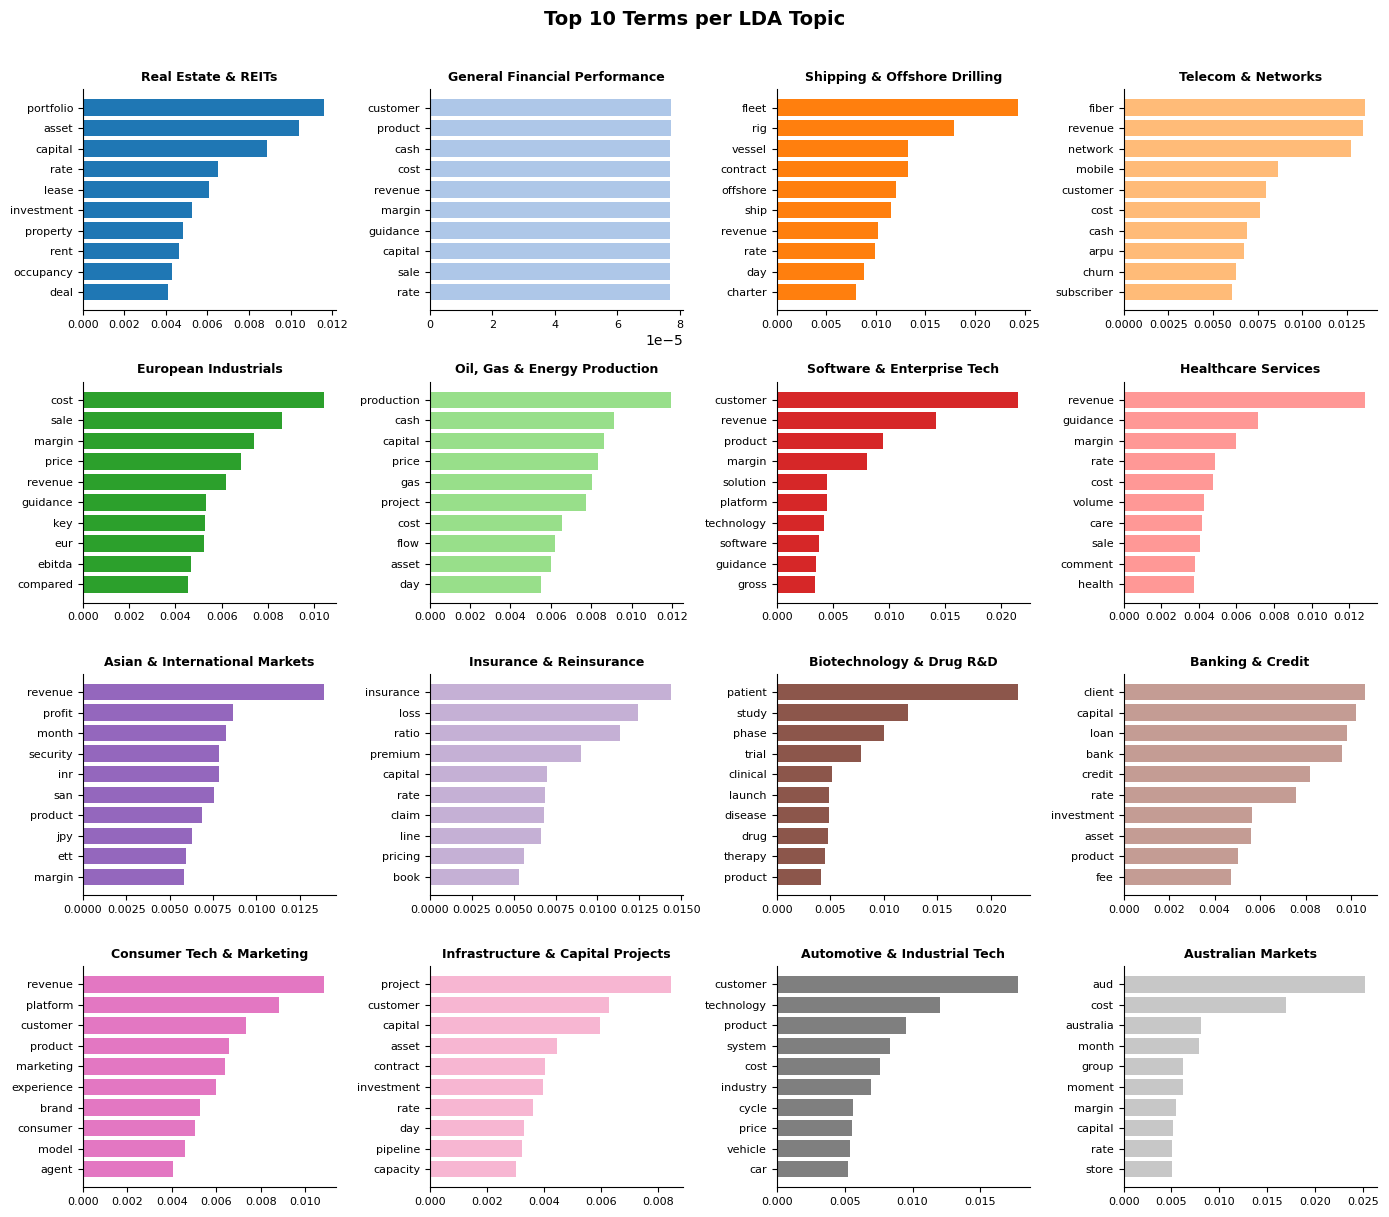

In [13]:
# --- Visualize top terms per topic (bar chart grid) ---

N_SHOW = min(K_FINAL, 16)  # max 16 topics in the grid
ncols = 4
nrows = int(np.ceil(N_SHOW / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3))
axes = axes.flatten()

for i in range(N_SHOW):
    terms = lda_model.show_topic(i, topn=10)
    words = [t[0] for t in terms]
    probs = [t[1] for t in terms]
    axes[i].barh(words[::-1], probs[::-1], color=plt.cm.tab20(i / K_FINAL))
    axes[i].set_title(TOPIC_LABELS[i], fontsize=9, fontweight='bold')
    axes[i].spines[['top', 'right']].set_visible(False)
    axes[i].tick_params(labelsize=8)

# Hide unused subplots
for j in range(N_SHOW, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Top 10 Terms per LDA Topic', fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/03_topic_top_terms.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Document-Topic Distributions

For each document, LDA estimates a distribution over K topics (the γ matrix). We extract this matrix and combine it with the corpus metadata (date, company, etc.) for export to R, where temporal and role-based visualizations will be produced.

In [14]:
# --- Extract document-topic distribution matrix (gamma) ---

print("Extracting document-topic distributions...")
gamma_rows = []
for i, bow_doc in enumerate(bow_corpus):
    topic_dist = dict(lda_model.get_document_topics(bow_doc, minimum_probability=0.0))
    row = {f"topic_{k}": topic_dist.get(k, 0.0) for k in range(K_FINAL)}
    gamma_rows.append(row)

gamma_df = pd.DataFrame(gamma_rows)

# Attach metadata — include temporal fields for R visualization
meta_cols = ['slug', 'url', 'company_name', 'ticker', 'quarter',
             'call_year', 'call_date', 'call_month', 'call_week',
             'reporting_period', 'event_type', 'n_words',
             'n_speaker_turns', 'n_exec_turns', 'n_analyst_turns']
# Only use columns that exist (robustness for older CSV versions)
meta_cols = [c for c in meta_cols if c in docs_clean.columns]
result_df = pd.concat([docs_clean[meta_cols].reset_index(drop=True), gamma_df], axis=1)

# Add dominant topic and its probability for each document
topic_cols_list = [f"topic_{k}" for k in range(K_FINAL)]
result_df['dominant_topic'] = gamma_df[topic_cols_list].idxmax(axis=1).str.replace('topic_', '').astype(int)
result_df['dominant_prob']  = gamma_df[topic_cols_list].max(axis=1)
result_df['dominant_label'] = result_df['dominant_topic'].map(TOPIC_LABELS)

print(f"Gamma matrix shape: {gamma_df.shape}")
print(f"\nDominant topic distribution:")
print(result_df['dominant_label'].value_counts().to_string())

Extracting document-topic distributions...


Gamma matrix shape: (2882, 20)

Dominant topic distribution:
dominant_label
Consumer Products & Pricing          506
Software & Enterprise Tech           377
European Industrials                 232
Infrastructure & Capital Projects    225
Real Estate & REITs                  223
European Energy & Materials          211
Healthcare Services                  196
Banking & Credit                     189
Biotechnology & Drug R&D             153
Oil, Gas & Energy Production         151
Consumer Tech & Marketing            111
Australian Markets                    72
Insurance & Reinsurance               62
Asian & International Markets         53
Telecom & Networks                    37
Shipping & Offshore Drilling          33
Automotive & Industrial Tech          32
Aerospace, Defense & Space            15
Education & Niche Sectors              4


In [15]:
# --- Export document-topic distributions (gamma) ---

result_df.to_csv('data/doc_topic_distributions.csv', index=False)
print(f"Saved data/doc_topic_distributions.csv ({len(result_df):,} rows)")

# --- Export topic-term distributions (beta) ---
# One row per (topic, term) pair with probability

beta_rows = []
for t in range(K_FINAL):
    for word, prob in lda_model.show_topic(t, topn=30):
        beta_rows.append({'topic': t, 'label': TOPIC_LABELS[t],
                          'term': word, 'probability': prob})

beta_df = pd.DataFrame(beta_rows)
beta_df.to_csv('data/topic_terms.csv', index=False)
print(f"Saved data/topic_terms.csv ({len(beta_df)} rows)")

Saved data/doc_topic_distributions.csv (2,882 rows)
Saved data/topic_terms.csv (600 rows)


## 6. Speaker Role Analysis

One of the distinctive features of earnings calls as a genre is their **dialogic structure**: the prepared remarks phase (executives speak) alternates with the Q&A phase (analysts ask questions, executives respond). If our hypothesis is correct, we should observe that executives and analysts mobilize distinct topical vocabularies:
- **Executives** tend to frame performance in terms of strategy, growth, and forward guidance
- **Analysts** tend to probe specific concerns: margins, competitive dynamics, sector-specific risks

We test this by fitting topic distributions separately on the executive-only and analyst-only subsets of the corpus.

In [16]:
# --- Load speaker-level corpus ---

speakers = pd.read_csv('data/corpus_speaker_level.csv')
print(f"Speaker turns: {len(speakers):,}")
print(f"Role distribution:")
print(speakers['role_type'].value_counts().to_string())

Speaker turns: 133,830
Role distribution:
role_type
executive    66001
analyst      40902
other        19526
operator      6456
ir             945


In [17]:
# --- Aggregate text by role type across all transcripts ---
# For topic comparison, we treat all executive speech as one large virtual
# document, and all analyst speech as another — then apply the trained model.

role_texts = {}
for role in ['executive', 'analyst']:
    role_df = speakers[speakers['role_type'] == role]
    # Tokenize individual turns, then flatten to one large token list
    all_toks = []
    for text in role_df['text']:
        all_toks.extend(preprocess(text))
    role_texts[role] = all_toks
    print(f"{role}: {len(role_df):,} turns → {len(all_toks):,} tokens")

executive: 66,001 turns → 1,614,552 tokens


analyst: 40,902 turns → 578,101 tokens


In [18]:
# --- Infer topic distributions for each role ---
# We use the trained LDA model (vocabulary and topic structure are fixed)
# and infer what topic mixture best explains each role's aggregate text.

role_topic_dists = {}
for role, tokens in role_texts.items():
    bow_role = dictionary.doc2bow(tokens)
    dist = lda_model.get_document_topics(bow_role, minimum_probability=0.0)
    role_topic_dists[role] = {k: v for k, v in dist}

# Build comparison DataFrame
role_compare = pd.DataFrame([
    {'role': role,
     'topic': TOPIC_LABELS[t],
     'topic_id': t,
     'proportion': role_topic_dists[role].get(t, 0.0)}
    for role in ['executive', 'analyst']
    for t in range(K_FINAL)
])

role_compare.to_csv('data/role_topic_comparison.csv', index=False)
print("Saved data/role_topic_comparison.csv")

Saved data/role_topic_comparison.csv


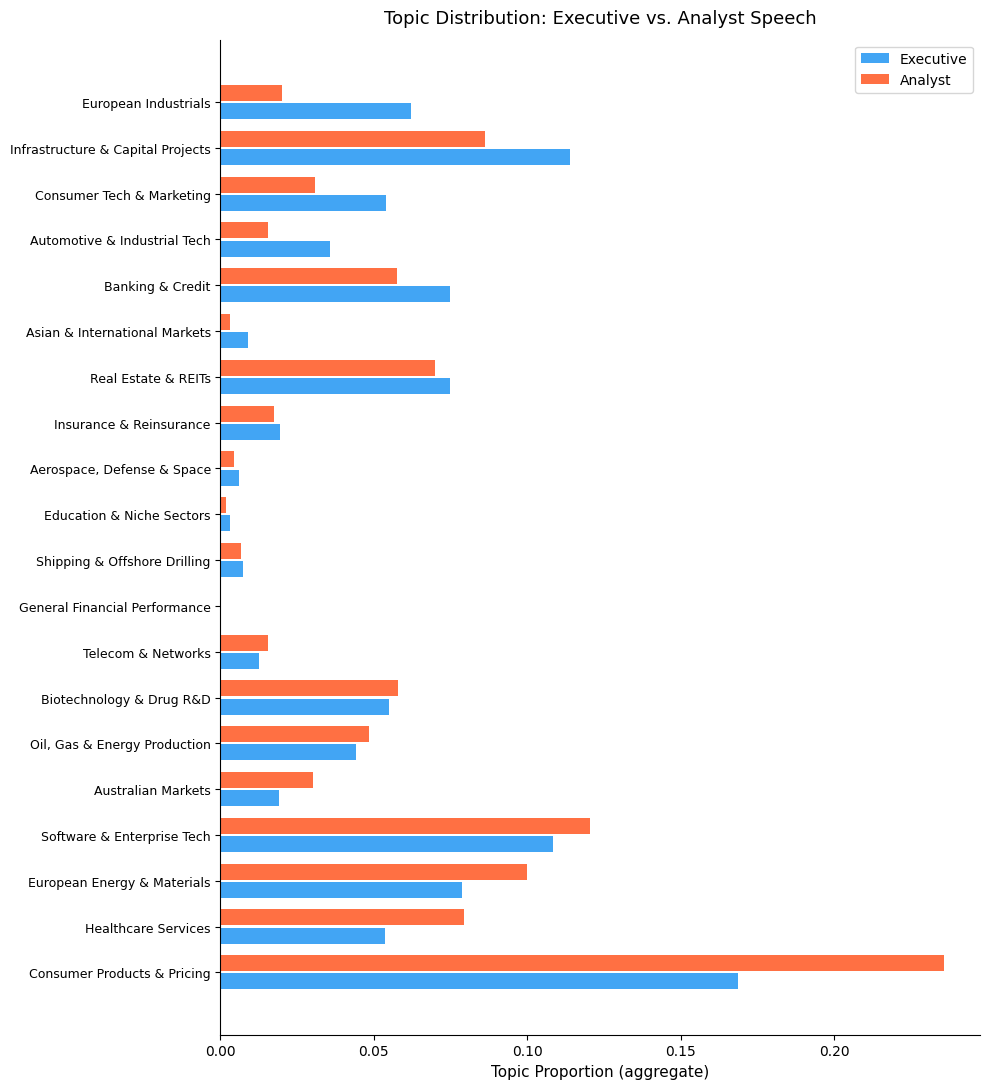


Topics most over-represented in EXECUTIVE speech:
role                               executive  analyst    diff
topic                                                        
European Industrials                  0.0619   0.0200  0.0419
Infrastructure & Capital Projects     0.1140   0.0861  0.0279
Consumer Tech & Marketing             0.0539   0.0306  0.0233

Topics most over-represented in ANALYST speech:
role                         executive  analyst    diff
topic                                                  
Consumer Products & Pricing     0.1685   0.2357 -0.0672
Healthcare Services             0.0536   0.0792 -0.0256
European Energy & Materials     0.0788   0.0998 -0.0210


In [19]:
# --- Visualize executive vs analyst topic profiles ---

pivot = role_compare.pivot(index='topic', columns='role', values='proportion').fillna(0)

# Sort by difference (topics where roles diverge most)
pivot['diff'] = pivot.get('executive', 0) - pivot.get('analyst', 0)
pivot = pivot.sort_values('diff')

fig, ax = plt.subplots(figsize=(10, 0.45 * K_FINAL + 2))

colors = {'executive': '#2196F3', 'analyst': '#FF5722'}
y_pos = np.arange(len(pivot))

if 'executive' in pivot.columns:
    ax.barh(y_pos - 0.2, pivot['executive'], height=0.35,
            label='Executive', color=colors['executive'], alpha=0.85)
if 'analyst' in pivot.columns:
    ax.barh(y_pos + 0.2, pivot['analyst'], height=0.35,
            label='Analyst', color=colors['analyst'], alpha=0.85)

ax.set_yticks(y_pos)
ax.set_yticklabels(pivot.index, fontsize=9)
ax.set_xlabel('Topic Proportion (aggregate)', fontsize=11)
ax.set_title('Topic Distribution: Executive vs. Analyst Speech', fontsize=13, pad=12)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('figures/04_executive_vs_analyst_topics.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTopics most over-represented in EXECUTIVE speech:")
print(pivot.nlargest(3, 'diff')[['executive', 'analyst', 'diff']].round(4))
print("\nTopics most over-represented in ANALYST speech:")
print(pivot.nsmallest(3, 'diff')[['executive', 'analyst', 'diff']].round(4))

## Summary and Handoff to R

This notebook has produced:

| File | Description |
|---|---|
| `data/doc_topic_distributions.csv` | γ matrix: one row per transcript, K topic proportions + metadata |
| `data/topic_terms.csv` | β matrix: top 30 terms per topic with probabilities |
| `data/role_topic_comparison.csv` | Topic proportions by speaker role (executive vs. analyst) |

These files are consumed by **`02_visualize_topics.R`**, which produces:
- Monthly topic prevalence plots (temporal evolution)
- Topic heatmaps across companies and time
- Executive vs. analyst topic divergence visualization

### Next steps (Part 2)
Having identified the main topical structure of the corpus, Part 2 will zoom in on a specific topic (e.g., AI/Technology or macroeconomic risk) to conduct a more granular analysis of how language around that topic evolves and which companies are its primary carriers.